In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_clean = pd.read_excel("../data/telco_churn_clean.xlsx")
print(df_clean.shape)       # sanity check — should show (7043, 22)
df_clean.head()

(7043, 22)


,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Los Angeles,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372
3,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340


In [2]:
from numpy.random import normal
df_clean['Churn Value'].value_counts()
df_clean['Churn Value'].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

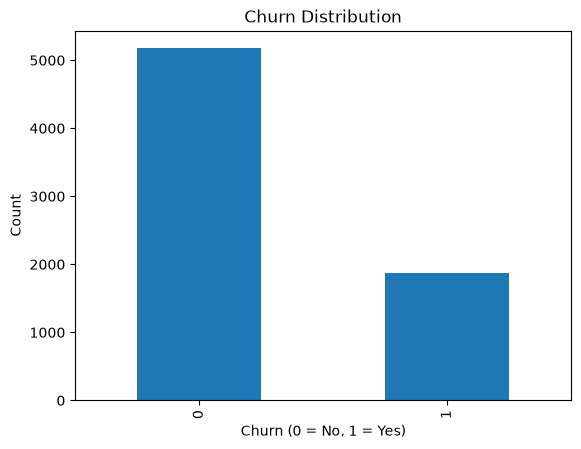

In [3]:
import matplotlib.pyplot as plt

df_clean['Churn Value'].value_counts().plot(kind='bar')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Churn Distribution')
plt.show()

In [4]:
# Compare tenure distributions for churned vs. not churned
df_clean.groupby('Churn Value')['Tenure Months'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


**Tenure vs Churn**

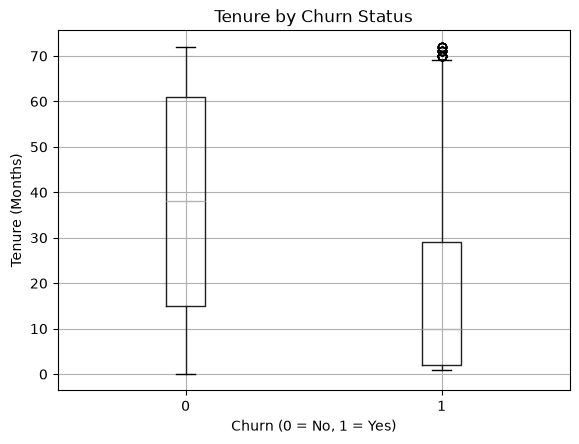

In [5]:
import matplotlib.pyplot as plt

df_clean.boxplot(column='Tenure Months', by='Churn Value')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure (Months)')
plt.title('Tenure by Churn Status')
plt.suptitle('')
plt.show()

**Monthly Charges vs Churn**

In [6]:
df_clean.groupby('Churn Value')['Monthly Charges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


*Contract vs Churn*

In [7]:
pd.crosstab(df_clean['Contract'], df_clean['Churn Value'], normalize='index')

Churn Value,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [8]:
pd.crosstab(df_clean['Contract'], df_clean['Churn Value'], normalize='index')

Churn Value,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Internet Service vs Churn value**

In [9]:
print(pd.crosstab(df_clean['Internet Service'], df_clean['Churn Value'], normalize='index'))


Churn Value              0         1
Internet Service                    
DSL               0.810409  0.189591
Fiber optic       0.581072  0.418928
No                0.925950  0.074050


**Payment method vs churn value**

In [10]:
print(pd.crosstab(df_clean['Payment Method'], df_clean['Churn Value'], normalize='index'))


Churn Value                       0         1
Payment Method                               
Bank transfer (automatic)  0.832902  0.167098
Credit card (automatic)    0.847569  0.152431
Electronic check           0.547146  0.452854
Mailed check               0.808933  0.191067


**Tenure Months vs Churn value**

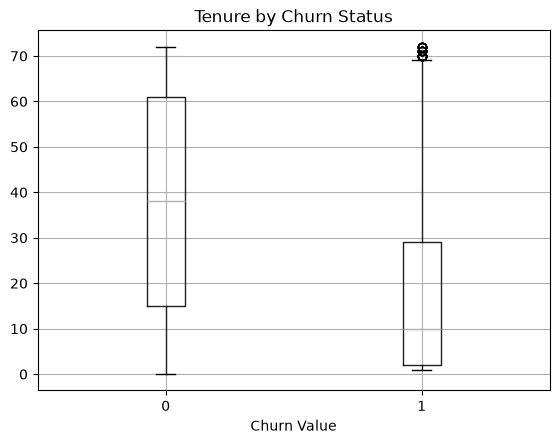

In [11]:
df_clean.boxplot(column='Tenure Months', by='Churn Value')
plt.title('Tenure by Churn Status'); plt.suptitle(''); plt.show()

**Correlation of numeric features with churn**

In [12]:
print(df_clean[['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Value']].corr()['Churn Value'])

Tenure Months     -0.352229
Monthly Charges    0.193356
Total Charges     -0.198324
CLTV              -0.127463
Churn Value        1.000000
Name: Churn Value, dtype: float64


|